In [7]:
import pandas as pd
import json

import random
import geopandas as gpd
import numpy as np
import os

enc = 'utf-8'
random.seed(0)
np.random.seed(0)


In [8]:
folder_path = 'shapefiles/EUROPE_NUTS_2021_4326'   

europe_nuts = gpd.read_file(f"{folder_path}/NUTS_RG_01M_2021_4326.shp",  encoding=enc)

In [10]:
with open('country_codes.json') as json_file:
    country_codes = json.load(json_file)

In [11]:
europe_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((14.49122 51.04353, 14.49945 51.04610..."
1,DE,0,DE,Deutschland,Deutschland,0.0,0,0,DE,"MULTIPOLYGON (((10.45444 47.55580, 10.43954 47..."
2,DK,0,DK,Danmark,Danmark,0.0,0,0,DK,"MULTIPOLYGON (((15.19308 55.32014, 15.19056 55..."
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"MULTIPOLYGON (((19.83100 42.46645, 19.83568 42..."
4,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"MULTIPOLYGON (((34.60609 35.70767, 34.60060 35..."
...,...,...,...,...,...,...,...,...,...,...
2005,UKM73,3,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1,1,UKM73,"MULTIPOLYGON (((-2.36662 55.94611, -2.36697 55..."
2006,UKM75,3,UK,"Edinburgh, City of","Edinburgh, City of",4.0,1,1,UKM75,"MULTIPOLYGON (((-3.07764 55.94689, -3.08167 55..."
2007,UKM76,3,UK,Falkirk,Falkirk,4.0,1,1,UKM76,"POLYGON ((-3.51572 56.00226, -3.51251 55.99411..."
2008,UKM78,3,UK,West Lothian,West Lothian,4.0,1,1,UKM78,"POLYGON ((-3.42533 55.99403, -3.42699 55.99050..."


In [12]:
europe_nuts['CNTR_NAME'] = europe_nuts['CNTR_CODE'].map(country_codes) 

In [13]:
europe_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,CNTR_NAME
0,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((14.49122 51.04353, 14.49945 51.04610...",Czech Republic
1,DE,0,DE,Deutschland,Deutschland,0.0,0,0,DE,"MULTIPOLYGON (((10.45444 47.55580, 10.43954 47...",Germany
2,DK,0,DK,Danmark,Danmark,0.0,0,0,DK,"MULTIPOLYGON (((15.19308 55.32014, 15.19056 55...",Denmark
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"MULTIPOLYGON (((19.83100 42.46645, 19.83568 42...",Albania
4,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"MULTIPOLYGON (((34.60609 35.70767, 34.60060 35...",Cyprus
...,...,...,...,...,...,...,...,...,...,...,...
2005,UKM73,3,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1,1,UKM73,"MULTIPOLYGON (((-2.36662 55.94611, -2.36697 55...",United Kingdom
2006,UKM75,3,UK,"Edinburgh, City of","Edinburgh, City of",4.0,1,1,UKM75,"MULTIPOLYGON (((-3.07764 55.94689, -3.08167 55...",United Kingdom
2007,UKM76,3,UK,Falkirk,Falkirk,4.0,1,1,UKM76,"POLYGON ((-3.51572 56.00226, -3.51251 55.99411...",United Kingdom
2008,UKM78,3,UK,West Lothian,West Lothian,4.0,1,1,UKM78,"POLYGON ((-3.42533 55.99403, -3.42699 55.99050...",United Kingdom


In [14]:
europe_nuts['NUTS_ID'].equals(europe_nuts['FID'])

True

In [15]:
europe_nuts.drop(columns=['FID'], inplace = True)

In [16]:
europe_nuts0 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 0].copy()
europe_nuts1 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 1].copy()
europe_nuts2 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 2].copy()
europe_nuts3 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 3].copy()

In [17]:
europe_nuts0.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts1.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts2.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts3.drop(columns=['LEVL_CODE'], inplace = True)

europe_nuts0.reset_index(drop=True, inplace=True)
europe_nuts1.reset_index(drop=True, inplace=True)
europe_nuts2.reset_index(drop=True, inplace=True)
europe_nuts3.reset_index(drop=True, inplace=True)

In [18]:
print(f'europe_nuts0 CRS: {europe_nuts0.crs}')
print(f'europe_nuts1 CRS: {europe_nuts1.crs}')
print(f'europe_nuts2 CRS: {europe_nuts2.crs}')
print(f'europe_nuts3 CRS: {europe_nuts3.crs}')

europe_nuts0 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts1 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts2 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [19]:
europe_nuts0 = europe_nuts0.to_crs(epsg=4326)
europe_nuts1 = europe_nuts1.to_crs(epsg=4326)
europe_nuts2 = europe_nuts2.to_crs(epsg=4326)
europe_nuts3 = europe_nuts3.to_crs(epsg=4326)

In [20]:
print(f'europe_nuts0 CRS: {europe_nuts0.crs}')
print(f'europe_nuts1 CRS: {europe_nuts1.crs}')
print(f'europe_nuts2 CRS: {europe_nuts2.crs}')
print(f'europe_nuts3 CRS: {europe_nuts3.crs}')

europe_nuts0 CRS: EPSG:4326
europe_nuts1 CRS: EPSG:4326
europe_nuts2 CRS: EPSG:4326
europe_nuts3 CRS: EPSG:4326


<Axes: >

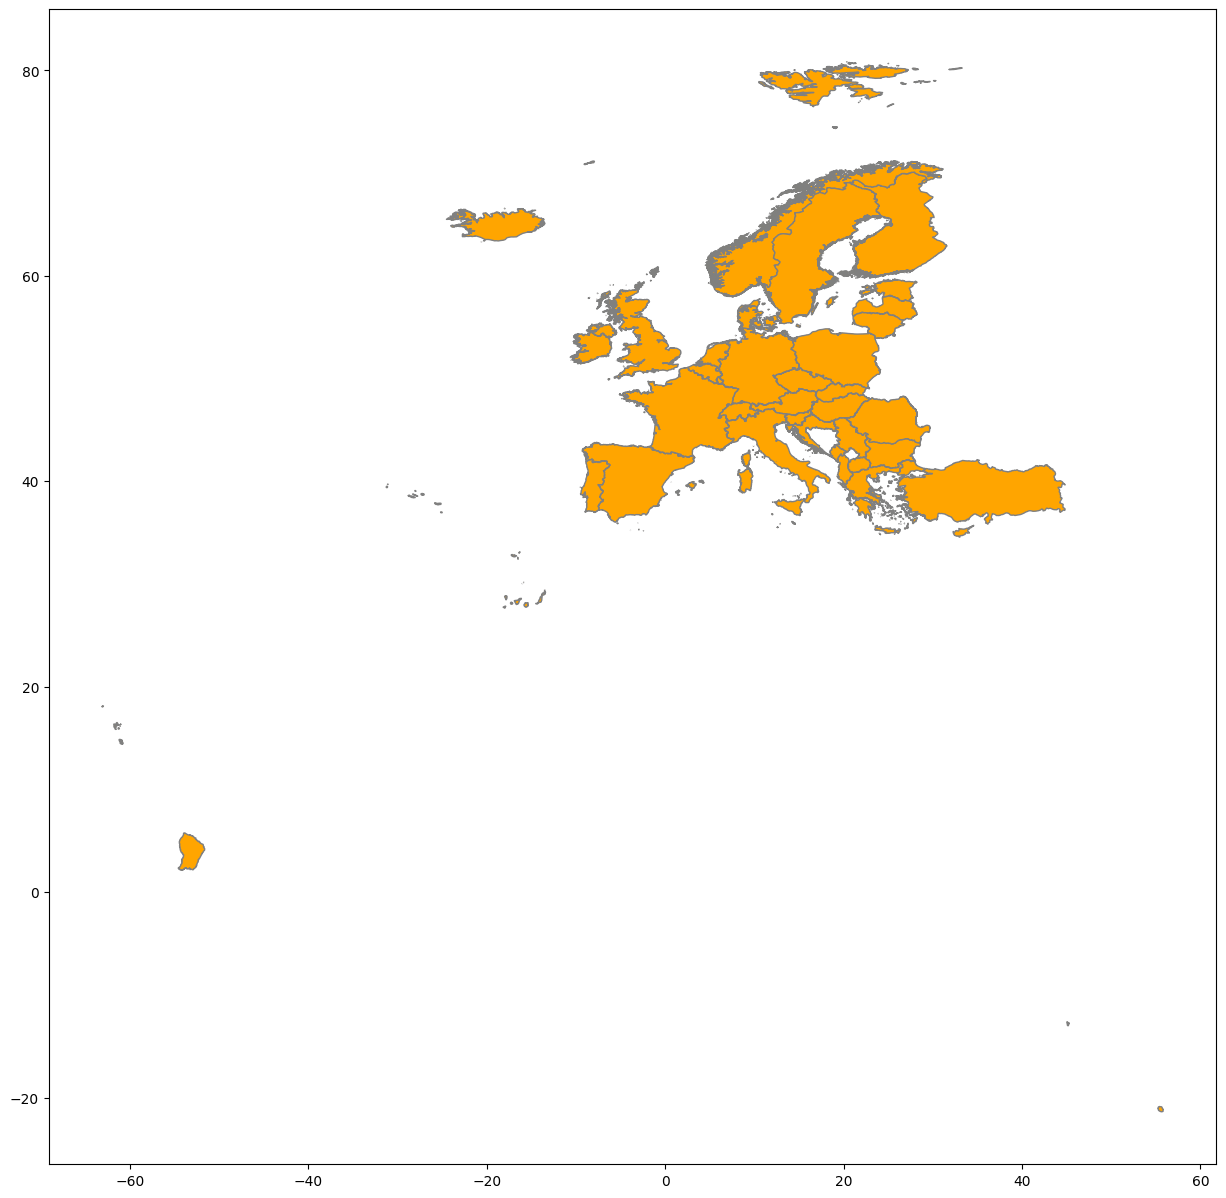

In [21]:
europe_nuts0.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<Axes: >

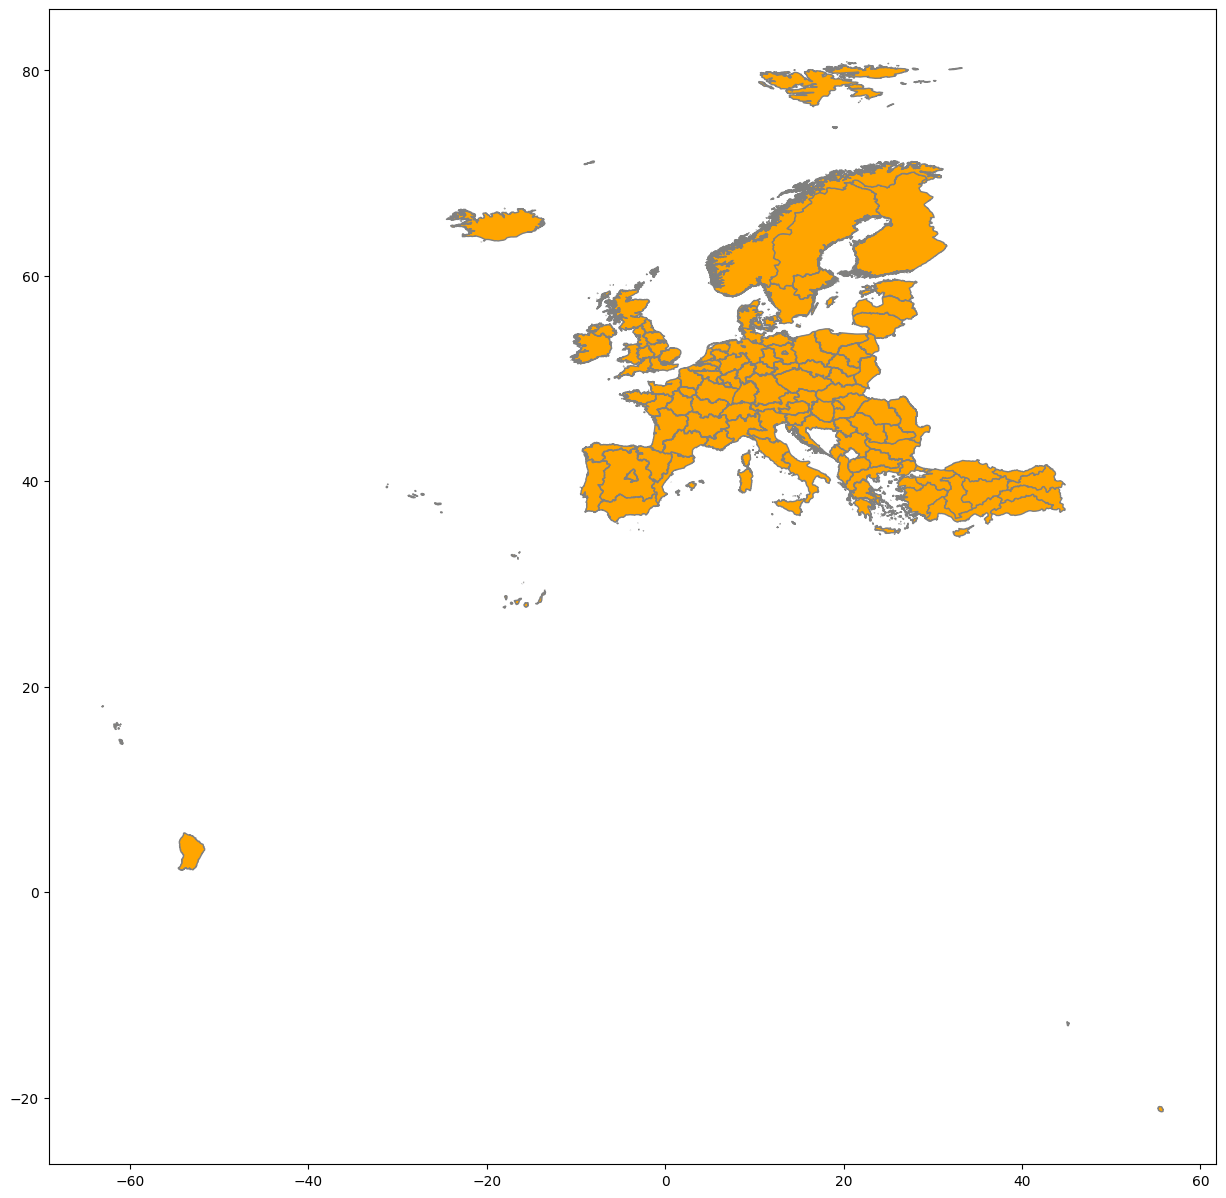

In [22]:
europe_nuts1.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<Axes: >

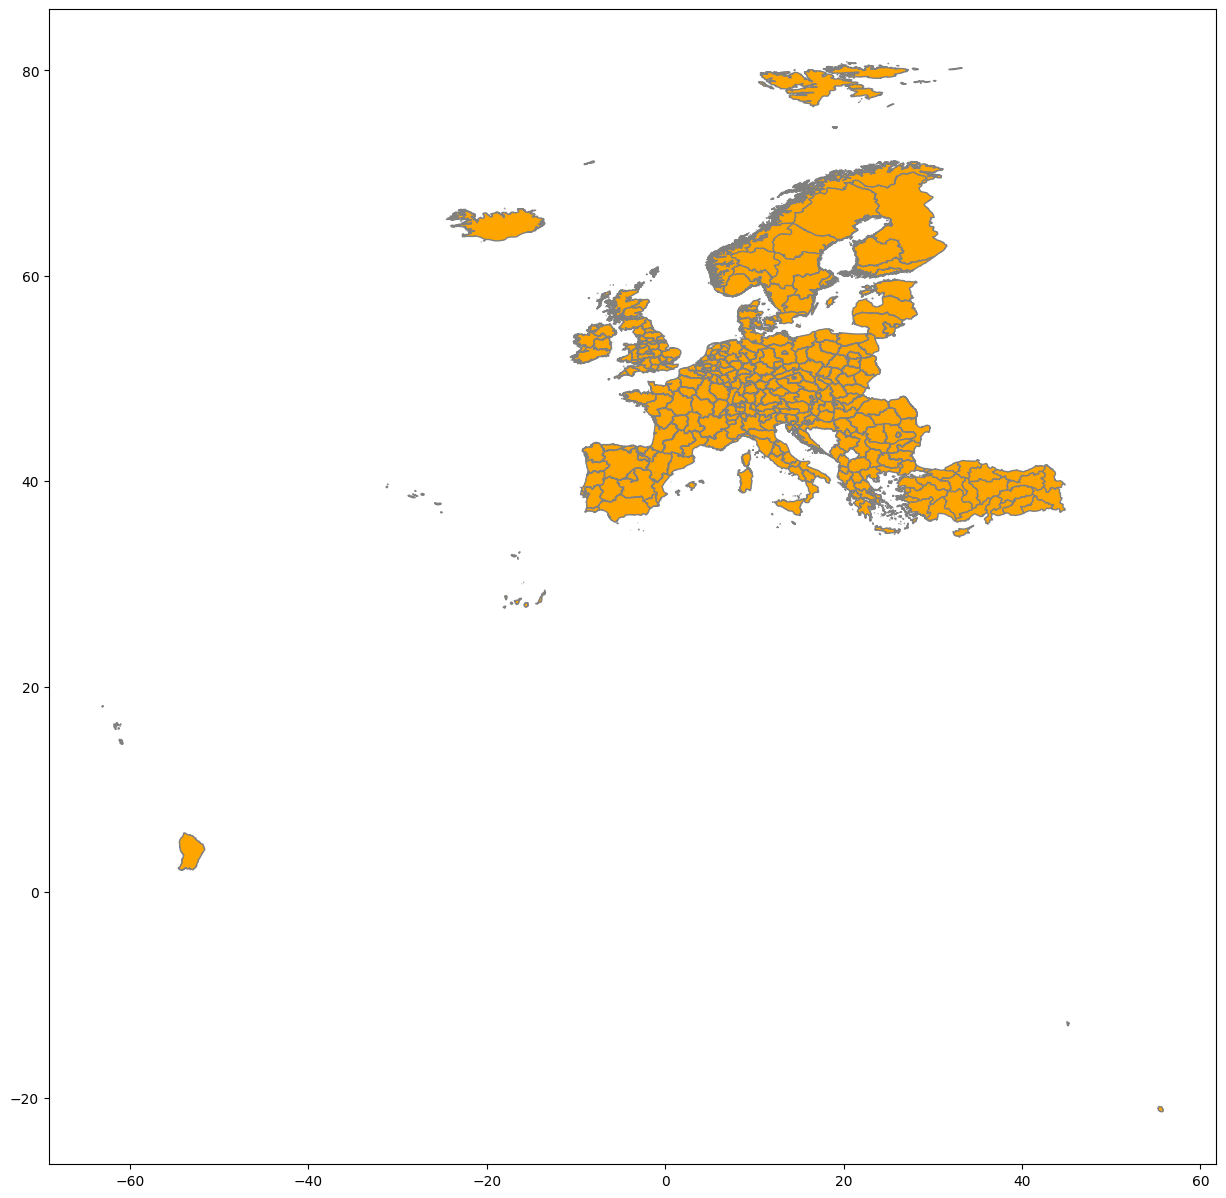

In [23]:
europe_nuts2.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<Axes: >

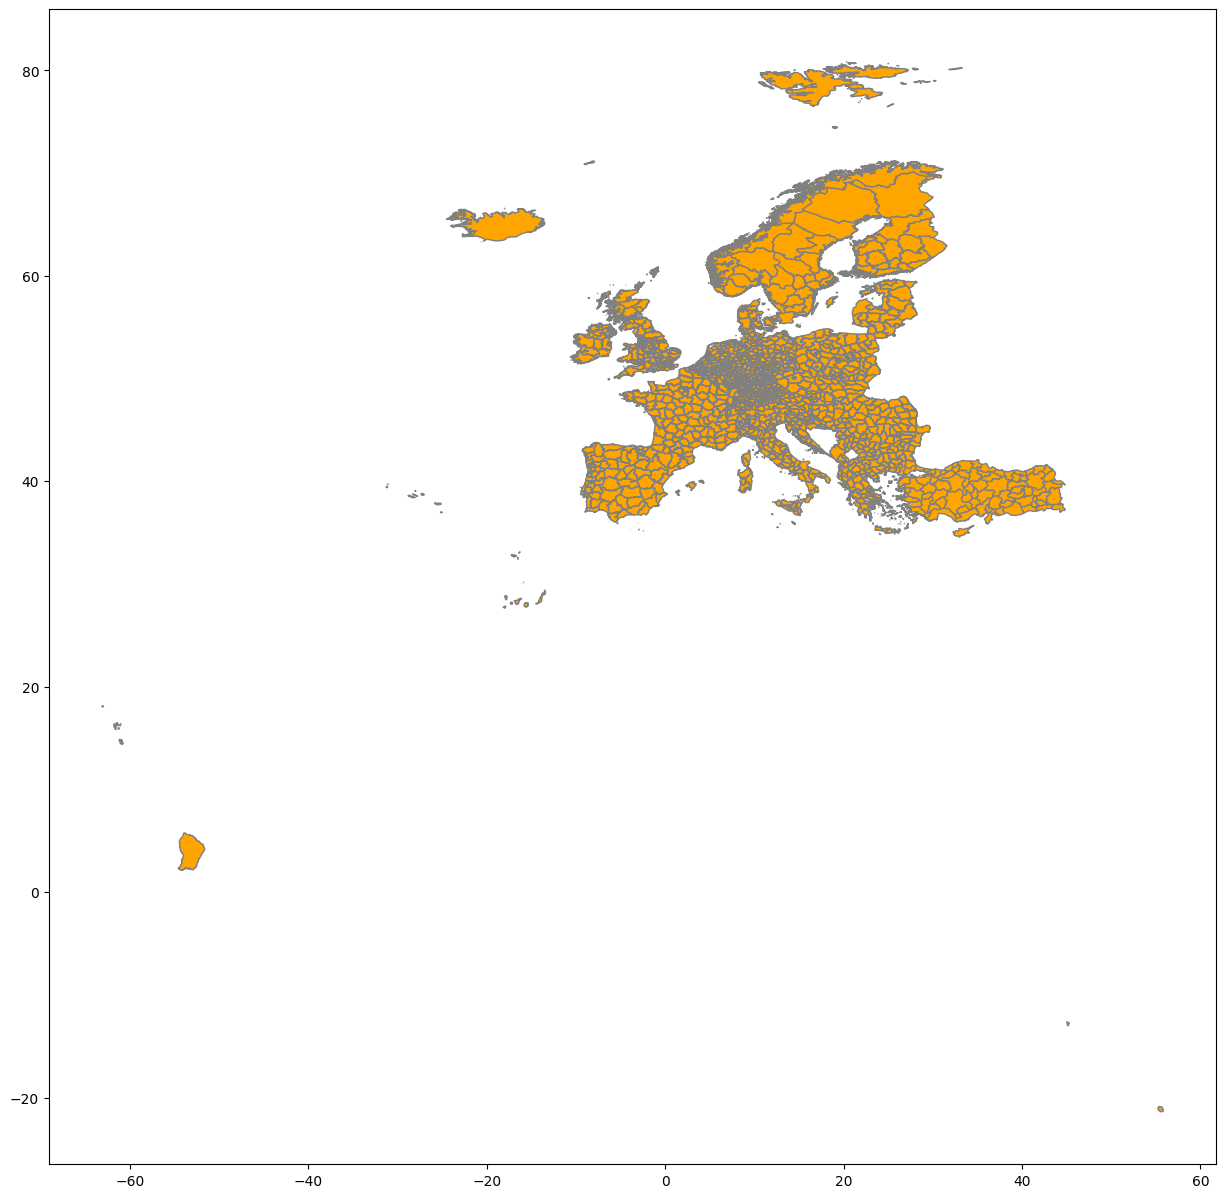

In [24]:
europe_nuts3.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

In [25]:
el0 = europe_nuts0.loc[europe_nuts0['CNTR_CODE'] == 'EL']
el1 = europe_nuts1.loc[europe_nuts1['CNTR_CODE'] == 'EL']
el2 = europe_nuts2.loc[europe_nuts2['CNTR_CODE'] == 'EL']
el3 = europe_nuts3.loc[europe_nuts3['CNTR_CODE'] == 'EL']

In [26]:
el0.reset_index(drop=True, inplace=True)
el1.reset_index(drop=True, inplace=True)
el2.reset_index(drop=True, inplace=True)
el3.reset_index(drop=True, inplace=True)

In [28]:
el3

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,CNTR_NAME
0,EL431,EL,Irakleio,Ηράκλειο,2.0,2,1,"MULTIPOLYGON (((25.49070 35.29833, 25.49187 35...",Greece
1,EL542,EL,Thesprotia,Θεσπρωτία,3.0,3,1,"MULTIPOLYGON (((20.39131 39.78848, 20.40219 39...",Greece
2,EL543,EL,Ioannina,Ιωάννινα,3.0,2,3,"POLYGON ((21.00401 40.15407, 20.97867 40.14482...",Greece
3,EL434,EL,Chania,Χανιά,2.0,2,1,"MULTIPOLYGON (((24.31741 35.35377, 24.32346 35...",Greece
4,EL511,EL,Evros,Έβρος,4.0,2,1,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41...",Greece
5,EL512,EL,Xanthi,Ξάνθη,2.0,2,1,"POLYGON ((25.17938 41.31019, 25.17954 41.30251...",Greece
6,EL653,EL,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1,"MULTIPOLYGON (((22.98080 37.04790, 22.99124 37...",Greece
7,EL645,EL,Fokida,Φωκίδα,3.0,3,1,"MULTIPOLYGON (((22.62763 38.31086, 22.62833 38...",Greece
8,EL301,EL,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545...",Greece
9,EL302,EL,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38...",Greece


In [30]:
el0.to_file('Greece/data/EL_NUTS0.shp', encoding = enc)
el1.to_file('Greece/data/EL_NUTS1.shp', encoding = enc)
el2.to_file('Greece/data/EL_NUTS2.shp', encoding = enc)
el3.to_file('Greece/data/EL_NUTS3.shp', encoding = enc)